In [1]:
# Basic Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# let's start with classification data and its evaluation metrics

In [3]:
# import data
heart_disease = pd.read_csv("heart-disease.csv")

heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
len(heart_disease),heart_disease.dtypes

(303,
 age           int64
 sex           int64
 cp            int64
 trestbps      int64
 chol          int64
 fbs           int64
 restecg       int64
 thalach       int64
 exang         int64
 oldpeak     float64
 slope         int64
 ca            int64
 thal          int64
 target        int64
 dtype: object)

In [8]:
# lets see if there are any missing values
heart_disease.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# since there are not any misssing values nor any no numeric data we can start fitting out model
# we are going to use ensemble models

In [21]:
# lets split the data into X and Y (Feature and Label Matrix)

# lets set the random seed
np.random.seed(42)

X = heart_disease.drop("target",axis=1)
Y = heart_disease["target"]

# lets split the data into train and test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# lets instanciate a model
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# lets fit the model
clf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## There are three different ways to evaluate the model
* Using built-in `score()` parameter
* The `Scoring()` using cross_val_score
* `Problem specific` metric functions

## 1. Using `Score()`

In [22]:
# lets use score
# The default scoring parameter for classification model is Accuracy
acc = clf.score(x_test,y_test)
print(f"The accuracy score of Random Forest Classifier is {acc*100:.2f}%")

The accuracy score of Random Forest Classifier is 85.25%


In [23]:
# what is accuracy and how is it calculated???
# step 1:- lets make the predictions using `predict()` function
y_preds = clf.predict(x_test)
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [24]:
# lets see the actual labels
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

In [25]:
# now lets calculate the mean of each predicted value which is equal to the actual value
score = np.mean(y_test == y_preds)
print(f"The mean accuracy of the Random Forest Classifier is {score * 100:.2f}%")

The mean accuracy of the Random Forest Classifier is 85.25%


### see the acc and score are equal

## 2. Using `Scoring` parameter

* we are goint to use cross_val_score

In [33]:
np.random.seed(42)
from sklearn.model_selection import cross_val_score

# the scoring used models default scoring metrics with not specified (i.e Accuracy for Classification)
cross_validated_score = cross_val_score(clf,X,Y,scoring=None)
np.mean(cross_validated_score)


np.float64(0.8248087431693989)

In [35]:
# now lets change it to precision
np.random.seed(42)
cross_validated_score = cross_val_score(clf,X,Y,scoring="precision") 
np.mean(cross_validated_score)

np.float64(0.8329547346025924)

In [36]:
# now lets change it to recall
np.random.seed(42)
cross_validated_score = cross_val_score(clf,X,Y,scoring="recall")
np.mean(cross_validated_score)

np.float64(0.8545454545454545)

In [37]:
np.random.seed(42)
f1_score = cross_val_score(clf,X,Y,scoring="f1")
np.mean(f1_score)

np.float64(0.8426854603423344)

## 3. Problem Specific Methods
 1. Accuracy
 2. Area Under Roc Curve
 3. Confusion Matrix
 4. Classification Report

# 1. Accuracy

In [39]:
# we have already dont this still

accuracy_score = cross_val_score(clf,X,Y)
accuracy_score

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

# 2. Area under ROC Curve
Receiver operating Characterstics Curve or 
Area Under Curve (AUC)

it is the measure of the models true positive rate and false positive rate



In [40]:
# lets split the data into train and test split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# lets innstanciate the model
clf = RandomForestClassifier()

# lets fit the model
clf.fit(x_train,y_train)

# lets make the prediction using predict proba as it give the probability of true or fasle predictions
y_preds = clf.predict_proba(x_test)

y_preds[:10]

array([[0.11, 0.89],
       [0.53, 0.47],
       [0.09, 0.91],
       [0.39, 0.61],
       [0.23, 0.77],
       [0.01, 0.99],
       [0.61, 0.39],
       [0.45, 0.55],
       [0.11, 0.89],
       [0.87, 0.13]])

In [41]:
# as it is the comparison between True `positive` and False `Positive` lets only keep the positive predictions i.e 1
y_preds_positive = y_preds[:, 1]
y_preds_positive[:10]

array([0.89, 0.47, 0.91, 0.61, 0.77, 0.99, 0.39, 0.55, 0.89, 0.13])

In [45]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold = roc_curve(y_test,y_preds_positive)

In [46]:
fpr

array([0.     , 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.0625 ,
       0.09375, 0.15625, 0.15625, 0.1875 , 0.1875 , 0.21875, 0.21875,
       0.3125 , 0.34375, 0.34375, 0.40625, 0.59375, 0.65625, 0.75   ,
       0.9375 , 1.     ])

In [49]:
tpr

array([0.        , 0.        , 0.13793103, 0.20689655, 0.34482759,
       0.44827586, 0.44827586, 0.48275862, 0.5862069 , 0.72413793,
       0.72413793, 0.86206897, 0.86206897, 0.89655172, 0.89655172,
       0.93103448, 0.96551724, 0.96551724, 0.96551724, 0.96551724,
       1.        , 1.        , 1.        ])

In [70]:
# lets make a function that plots roc curve
def plot_roc_curve(fpr,tpr):
    fig,ax = plt.subplots()
    roc = ax.plot(fpr,tpr,label="ROC",color="yellow")
    ax.set(title="Roc Curve",xlabel="False Positive Rate (FPR)",ylabel="True Positive Rate(TPR)")
    ax.legend()
    

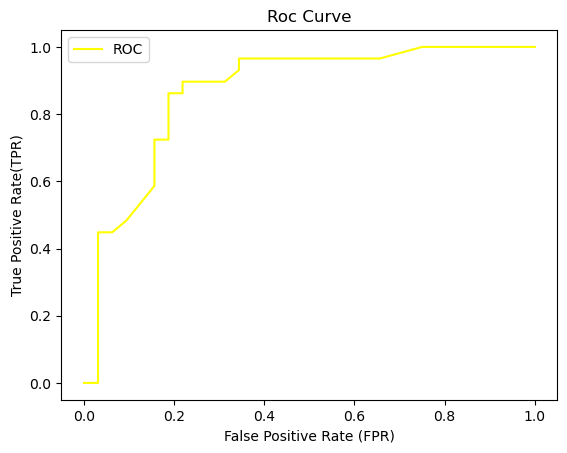

In [71]:
plot_roc_curve(fpr,tpr)

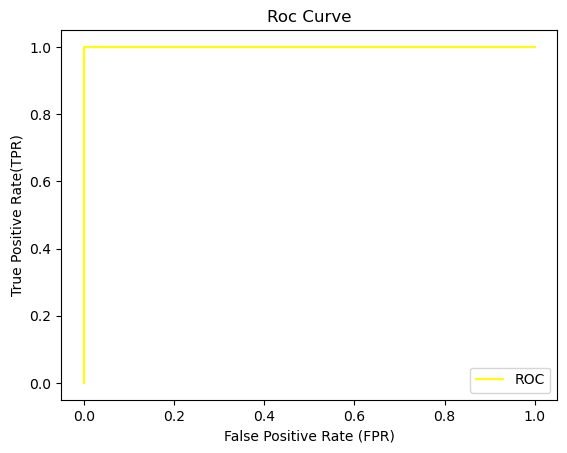

In [72]:
# what do you think and ideal plot looks like??
fpr,tpr,threshold = roc_curve(y_test,y_test)
plot_roc_curve(fpr,tpr)

# 3. Confustion matrix

In [79]:
from sklearn.metrics import confusion_matrix
y_preds = clf.predict(x_test)
mat = confusion_matrix(y_test,y_preds)
mat

array([[24,  8],
       [ 3, 26]])

In [80]:
# lets make it more visible
pd.crosstab(y_test,y_preds,rownames=["Actual Labels"],colnames=["Predicted Labels"])

Predicted Labels,0,1
Actual Labels,,
0,24,8
1,3,26


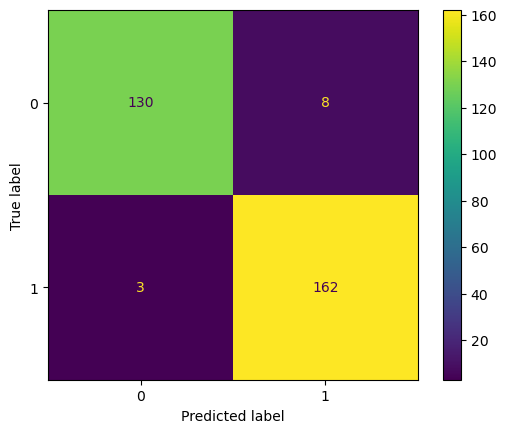

In [84]:
# lets make it more visual
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(estimator=clf,X=X,y=Y)

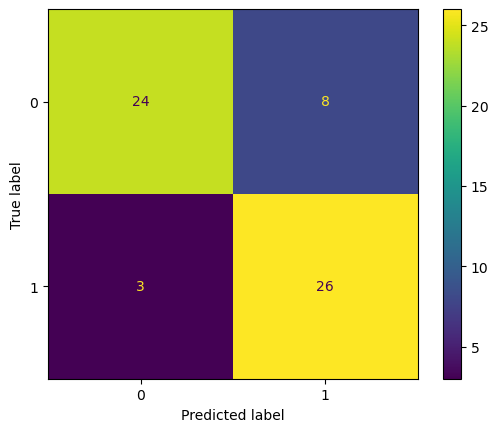

In [85]:
ConfusionMatrixDisplay.from_predictions(y_test,y_preds)

In [88]:
# 4. Classification Report
from sklearn.metrics import classification_report
report = classification_report(y_test,y_preds)

In [89]:
print(report)

              precision    recall  f1-score   support

           0       0.89      0.75      0.81        32
           1       0.76      0.90      0.83        29

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



# Now lets evaluate Regression model

* The Ones that we are going to cover are:-
   1. R^2 or (r squared)
   2. Mean Absolute Error (MAE)
   3. Mean Squared Error (MSE)

In [90]:
# first lets import dataset we will be using california housing datasets
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [95]:
housing_df = pd.DataFrame(housing["data"],columns=housing["feature_names"])
housing_df["target"] = housing["target"]

In [96]:
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [97]:
len(housing_df)

20640

In [98]:
housing_df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [104]:
# now lets split the data into feature and label matrix or (X and Y)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

# lets split the data into train and test split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# lets instianciate the model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()

# lets fit the model
model.fit(x_train,y_train)

# make predictions
y_preds = model.predict(x_test)

In [101]:
# default scoring parameter for regression model is coefficient or determination or (r^2 score)
model.score(x_test,y_test)

0.7999100067710789

In [105]:
from sklearn.metrics import r2_score
r2_score(y_test,y_preds)

0.8114935657949511

# Mean Squared Error(MSE)

In [107]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_preds)

0.24479041654531838

In [108]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_preds)

0.3252171841569769